# LIME — a step-by-step walkthrough (breast cancer, real data)

569 real patients, a real 30-feature RandomForest, a real decision
boundary. We build a LIME explanation one layer at a time, then measure
how much of it survives scrutiny — including the parts that do not.

**What you should be able to do afterwards**

1. State what LIME optimizes and name each term of its objective.
2. Follow the mechanism end to end: perturb → predict → weight → fit.
3. Say which parts of a local explanation are trustworthy (direction) and
   which are not (level), and cite the measurement that separates them.
4. Explain why the neighborhood LIME builds is not made of plausible
   patients, and what that costs.

Everything asserted here is measured in this notebook or in its companion,
`lime_internals.ipynb`, which validates each formula against the source
code of the `lime` package.

## Setup

In [1]:
%pip install -q lime scikit-learn matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, roc_auc_score

from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
BLUE = "#315B86"        # benign
TERRACOTTA = "#C96F3F"  # malignant
DARK = "#252525"
GRAY = "#A8A8A8"

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11, "figure.dpi": 140})

## What LIME is

Many models — like the 300-tree RandomForest used here — are black boxes:
they predict well, but you cannot read the "why" off their parameters.
LIME (*Local Interpretable Model-agnostic Explanations*, Ribeiro, Singh &
Guestrin, 2016) does not try to explain the whole model. It explains its
behavior **near one prediction**, by approximating it there with a simple
model — a straight line.

In one sentence: generate synthetic neighbors, ask the real model what it
thinks of each, and fit a weighted regression to those answers, giving
more weight to neighbors closer to the point.

## What we are optimizing

$$\xi(x) = \operatorname*{arg\,min}_{g \,\in\, G} \;\; \mathcal{L}(f, g, \pi_x) \, + \, \Omega(g)$$

| symbol | what it is | here |
|---|---|---|
| $f$ | the real model (black box) | the 300-tree RandomForest |
| $g$ | the local interpretable model | a Ridge regression |
| $\pi_x$ | proximity weight of neighbor $z$ to $x$ | $\pi_x(z) = \sqrt{\exp(-d(x,z)^2/\nu^2)}$ |
| $\mathcal{L}$ | how badly $g$ reproduces $f$ nearby | squared error, weighted by $\pi_x$ |
| $\Omega(g)$ | complexity penalty on $g$ | two things: only 8 of 30 features are kept, and those get an L2 (Ridge, $\alpha=1$) penalty |

One configuration choice worth flagging up front, because it changes what
the output looks like: we pass `discretize_continuous=False`. The package
default is `True`, which bins each feature into quartiles and produces
explanations phrased as intervals ("`worst perimeter` > 120") — the form
you will see in Molnar's book and in most tutorials. Turning it off keeps
the features continuous, which is what lets us draw the explanation as a
line in the plane. Same algorithm, different presentation.

## The model, and how the patient was chosen

**The model.** 300 trees, `min_samples_leaf=3`, not tuned by
cross-validation — a common manual choice (sklearn's default is 100).

**The patient.** Test patient #67. Two things determined the choice, and
it is worth being exact about them, because a vaguer version of this
paragraph was wrong in an earlier draft of this notebook.

1. She sits **near the decision boundary**. This is not cosmetic: the
   distance from the patient to the fit's $P=0.5$ contour equals
   $\lvert g(x)-0.5\rvert / \lVert w\rVert$, so for a confidently
   classified patient that line is *forced* far away and the figure
   degenerates into two unrelated lines.
2. The **plotting axes** are her highest-weight feature
   (`worst perimeter`), plus the highest-ranked feature in her top-8 that
   is not strongly correlated with it (`worst texture`, $r=0.35$). They
   are ranks 1 and 3, **not** the top two: rank 2 is
   `worst concave points`, which correlates with rank 1 at $r=0.81$ and
   would flatten the real patients onto a near 1-D ribbon with no 2-D
   structure to show.

This is a choice made for legibility, not a property of the data. Three
other test patients satisfy the same conditions (`lime_internals.ipynb`
§3); #67 is used because her plottable second axis sits highest in the
ranking. There is nothing unique about her, and the ranking itself shifts
between runs — a limitation of the method rather than a detail of our
setup.

In [3]:
data = load_breast_cancer()
X_all, y_all = data.data, data.target
feature_names = list(data.feature_names)
class_names = list(data.target_names)  # ['malignant', 'benign']
feat_idx = {f: i for i, f in enumerate(feature_names)}

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=RANDOM_STATE, stratify=y_all
)
model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

proba_test = model.predict_proba(X_test)[:, 1]
test_acc = accuracy_score(y_test, model.predict(X_test))
test_auc = roc_auc_score(y_test, proba_test)

instance_idx = 67
row = X_test[instance_idx]
row_proba = proba_test[instance_idx]
predicted = class_names[int(row_proba >= 0.5)]
true_label = class_names[y_test[instance_idx]]

train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)
row_scaled = (row - train_mean) / train_std
kernel_width = 0.75 * np.sqrt(len(feature_names))

axis_x_name, axis_y_name = "worst perimeter", "worst texture"
ix, iy = feat_idx[axis_x_name], feat_idx[axis_y_name]

print(f"patient #{instance_idx}: P(benign)={row_proba:.3f}  predicted={predicted}  true={true_label}")
print(f"model: test accuracy={test_acc:.1%}  ROC-AUC={test_auc:.3f}")
print(f"plot axes: {axis_x_name}={row[ix]:.1f} | {axis_y_name}={row[iy]:.1f}  "
      f"(correlation {np.corrcoef(X_train[:, ix], X_train[:, iy])[0, 1]:+.2f})")


def boundary_slice(clf, base_row, grid_x, grid_y):
    """The model's real decision surface, sliced along the plane of the 2
    chosen axes with the other 28 features frozen at THIS patient's values.
    The slice is computed exactly; but note it is itself a set of
    hypothetical patients — freezing 28 correlated measurements while two
    vary produces combinations that do not occur in reality. The same
    objection we will raise against LIME's own sampling applies here."""
    GX, GY = np.meshgrid(grid_x, grid_y)
    points = np.tile(base_row, (GX.size, 1))
    points[:, ix] = GX.ravel()
    points[:, iy] = GY.ravel()
    proba = clf.predict_proba(points)[:, 1]
    return GX, GY, proba.reshape(GX.shape)


# One window for every plot: ±1.5σ around the patient, clipped to the real
# data range. Fixed, so nothing moves between steps except what LIME adds.
WINDOW = 1.5
lo_x, hi_x = X_all[:, ix].min(), X_all[:, ix].max()
lo_y, hi_y = X_all[:, iy].min(), X_all[:, iy].max()
grid_x = np.linspace(max(lo_x, row[ix] - WINDOW * train_std[ix]), min(hi_x, row[ix] + WINDOW * train_std[ix]), 220)
grid_y = np.linspace(max(lo_y, row[iy] - WINDOW * train_std[iy]), min(hi_y, row[iy] + WINDOW * train_std[iy]), 200)
GX, GY, PROB_SLICE = boundary_slice(model, row, grid_x, grid_y)
print(f"P over this window spans {PROB_SLICE.min():.2f}–{PROB_SLICE.max():.2f}; "
      f"crosses 0.5: {PROB_SLICE.min() < 0.5 < PROB_SLICE.max()}")

patient #67: P(benign)=0.581  predicted=benign  true=benign
model: test accuracy=95.1%  ROC-AUC=0.993
plot axes: worst perimeter=113.1 | worst texture=19.1  (correlation +0.35)
P over this window spans 0.42–0.70; crosses 0.5: True


## Drawing tools

Real patients are drawn as **circles** coloured by their *true diagnosis*;
synthetic neighbors as **squares** coloured by the *model's prediction*.
Two different variables, two different shapes — an earlier version of
these figures used the same marker for both and was unreadable.

In [4]:
FIG_DIR = "figures_generated"  # regenerated on each run; committed copies live in ../figures
os.makedirs(FIG_DIR, exist_ok=True)


def new_figure(title, figsize=(8.5, 6.6)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(title, loc="left", fontsize=15, fontweight="bold", pad=12)
    return fig, ax


def draw_base(ax):
    ax.scatter(X_all[y_all == 1, ix], X_all[y_all == 1, iy], s=20, color=BLUE, alpha=0.45,
               linewidth=0, label="real patient · benign")
    ax.scatter(X_all[y_all == 0, ix], X_all[y_all == 0, iy], s=20, color=TERRACOTTA, alpha=0.45,
               linewidth=0, label="real patient · malignant")
    ax.contour(GX, GY, PROB_SLICE, levels=[0.5], colors=[DARK], linewidths=1.8, linestyles="--")
    ax.plot([], [], color=DARK, linewidth=1.8, linestyle="--", label="model boundary (P=0.5)")
    ax.set_xlim(grid_x.min(), grid_x.max())
    ax.set_ylim(grid_y.min(), grid_y.max())
    ax.set_xlabel(axis_x_name, fontsize=11)
    ax.set_ylabel(axis_y_name, fontsize=11)
    ax.tick_params(labelsize=9.5)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)


def draw_patient(ax, annotate=False):
    ax.scatter(row[ix], row[iy], s=220, marker="x", color=DARK, linewidths=3.2,
               zorder=20, label=f"patient #{instance_idx}")
    if annotate:
        ax.annotate(f"P(benign) = {row_proba:.3f}", (row[ix], row[iy]),
                    xytext=(12, 14), textcoords="offset points", fontsize=10,
                    color=DARK, fontweight="bold")


def draw_reference_ellipse(ax):
    ax.add_patch(Ellipse((row[ix], row[iy]),
                         width=2.4 * train_std[ix], height=2.4 * train_std[iy],
                         fill=False, color=DARK, linewidth=1.4, linestyle=(0, (4, 4)), alpha=0.85))
    ax.plot([], [], color=DARK, linewidth=1.4, linestyle=(0, (4, 4)), alpha=0.85,
            label="±1.2σ reference (not LIME's kernel)")


def draw_neighbors(ax, Z, colors=GRAY, sizes=26, alphas=0.6, labels=None):
    """Synthetic neighbors as squares, so they cannot be mistaken for real patients."""
    ax.scatter(Z[:, ix], Z[:, iy], s=sizes, marker="s", color=colors, alpha=alphas,
               linewidth=0.3, edgecolors="white")
    if labels:
        for c, lab in labels:
            ax.scatter([], [], s=40, marker="s", color=c, alpha=0.85,
                       linewidth=0.3, edgecolors="white", label=lab)


def local_isoline(exp, base_row, grid_x, grid_y):
    """The contour of g through the patient: {z : g(z) = g(x)}.

    Deliberately NOT the P=0.5 contour. Both have the same slope, but the
    0.5 contour's *position* is set by the intercept, which this notebook
    measures to be systematically biased (see the fidelity section). The
    contour through g(x) drops the intercept entirely, so it depends only
    on the coefficient ratio — the part that is faithful — and passes
    through the patient by construction."""
    cm = dict(exp.local_exp[1])
    base_scaled = (base_row - train_mean) / train_std
    gx_scaled = (grid_x - train_mean[ix]) / train_std[ix]
    y_scaled = base_scaled[iy] - (cm[ix] / cm[iy]) * (gx_scaled - base_scaled[ix])
    y_line = y_scaled * train_std[iy] + train_mean[iy]
    inside = (y_line >= grid_y.min()) & (y_line <= grid_y.max())
    return y_line, inside


def draw_local_fit(ax, exp):
    cm = dict(exp.local_exp[1])
    if ix not in cm or iy not in cm or abs(cm[iy]) < 1e-9:
        return False
    y_line, inside = local_isoline(exp, row, grid_x, grid_y)
    if inside.any():
        ax.plot(grid_x[inside], y_line[inside], color=DARK, linewidth=3,
                label="local fit (through the patient)")
        return True
    return False


def add_legend(ax, ncol=1):
    ax.legend(loc="upper left", fontsize=8.5, frameon=True, framealpha=0.93,
              edgecolor="none", ncol=ncol)


def save_figure(fig, name):
    fig.savefig(os.path.join(FIG_DIR, f"{name}.png"), dpi=200, bbox_inches="tight")

## Step 1 — the black-box model

A classifier returning P(benign) for any patient. We never look inside;
we only call `predict_proba()`.

**What to look for:** the dashed line is the model's decision boundary in
this slice, and the ✕ sits on it. It is a staircase, not a smooth curve —
a forest splits one feature at a time. Read the boundary's *position*
with some caution: across 12 other forest seeds its distance to the
patient ranges from 0.06σ to 0.48σ, so its exact placement is a property
of this particular fit, not a fact about breast cancer.

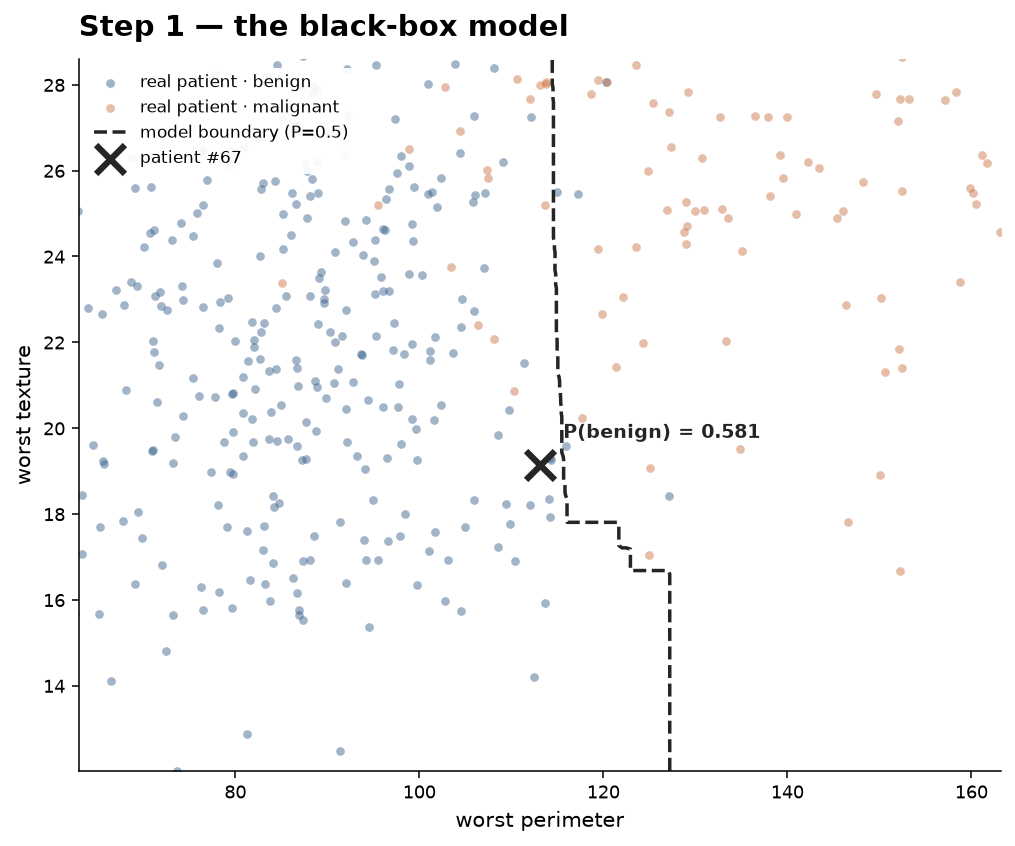

In [5]:
fig, ax = new_figure("Step 1 — the black-box model")
draw_base(ax)
draw_patient(ax, annotate=True)
add_legend(ax)
save_figure(fig, "lime_step_1")
plt.show()

## Step 2 — the local neighborhood

LIME needs a notion of "near". Each feature has its own scale, so each
gets its own width (its σ in the training set).

**What to look for, and an important correction:** the dashed ellipse is
a **reference at ±1.2σ**, drawn so you can see the idea of a
scale-adjusted neighborhood. It is *not* LIME's kernel. Because both plot
axes are scaled by their own σ, this ellipse renders as a circle no
matter what the feature scales are — do not read shape into it. And
LIME's actual neighborhood is far larger than the frame: the median
synthetic neighbor sits about 6σ away in 30-D and still carries about a
third of the maximum weight, with an effective sample size of roughly 93%
of the draws. The kernel localizes much less than its name suggests, and
that will matter twice before the notebook ends.

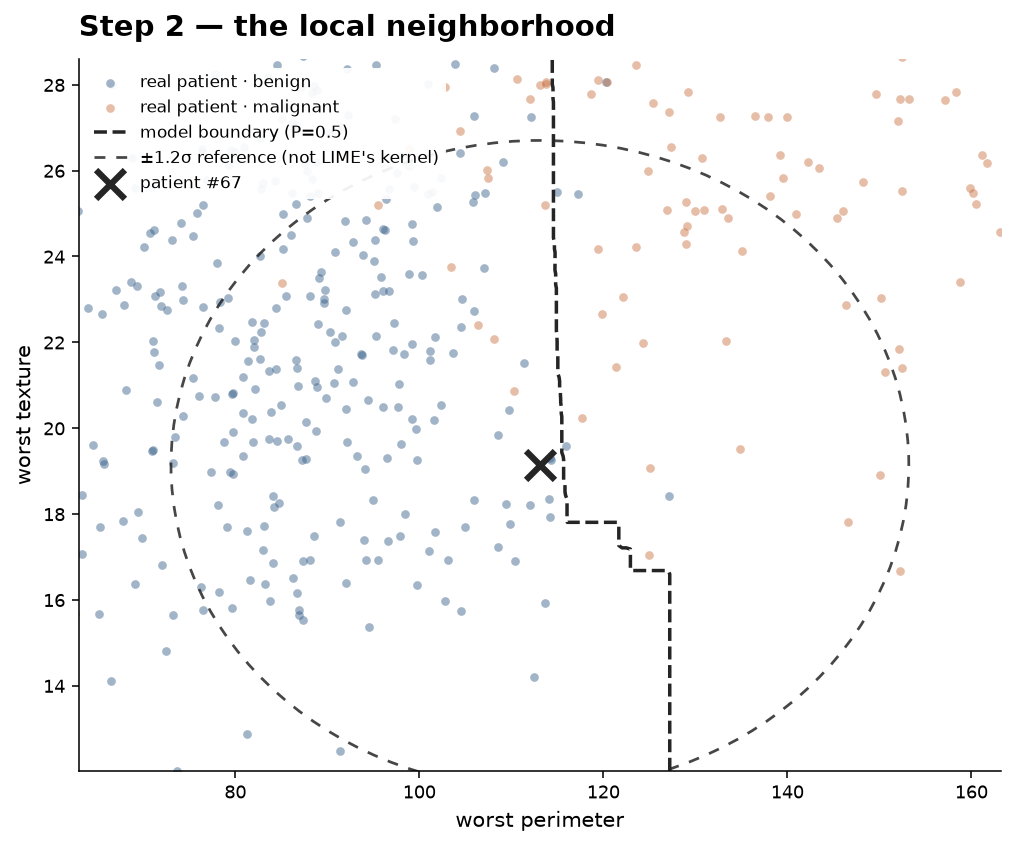

In [6]:
fig, ax = new_figure("Step 2 — the local neighborhood")
draw_base(ax)
draw_reference_ellipse(ax)
draw_patient(ax)
add_legend(ax)
save_figure(fig, "lime_step_2")
plt.show()

## Step 3 — perturbation, and what is wrong with it

$$z = \mu + \sigma \cdot \mathcal{N}(0,1)$$

across all 30 features at once, each with its own training mean and σ.
Note what this says: the cloud is centred on the **dataset**, not on the
patient (`sample_around_instance=False` is the package default). Every
patient in this dataset gets essentially the same cloud; only the weights
in step 5 differ.

**The caveat that matters most in this notebook.** Sampling each feature
independently destroys the correlations that make a patient physically
possible. The cell below measures the damage. It is not a rounding error:
a large majority of the synthetic "patients" have at least one negative
measurement — negative radius, negative area — and the ratio between
`worst perimeter` and `worst radius`, which is $\approx 2\pi$ for any real
closed shape, ranges over more than an order of magnitude.

This is not a footnote about LIME. It is the mechanism behind the result
in the fidelity section below.

In [7]:
rng_vis = np.random.RandomState(RANDOM_STATE)
N_VIS = 500
Z_vis = train_mean + train_std * rng_vis.normal(0, 1, size=(N_VIS, len(feature_names)))

# how impossible is this cloud, really?
rng_big = np.random.RandomState(RANDOM_STATE + 1)
Z_big = train_mean + train_std * rng_big.normal(0, 1, size=(5000, len(feature_names)))
frac_negative = (Z_big < 0).any(axis=1).mean()
ratio_syn = Z_big[:, feat_idx["worst perimeter"]] / Z_big[:, feat_idx["worst radius"]]
ratio_real = X_all[:, feat_idx["worst perimeter"]] / X_all[:, feat_idx["worst radius"]]
in_window = ((Z_vis[:, ix] >= grid_x.min()) & (Z_vis[:, ix] <= grid_x.max()) &
             (Z_vis[:, iy] >= grid_y.min()) & (Z_vis[:, iy] <= grid_y.max()))

print(f"synthetic patients with at least one NEGATIVE measurement: {frac_negative:.0%}")
print(f"worst perimeter / worst radius  —  real data: "
      f"[{ratio_real.min():.2f}, {ratio_real.max():.2f}]   (2π = {2*np.pi:.2f})")
print(f"worst perimeter / worst radius  —  synthetic (1–99 pct): "
      f"[{np.percentile(ratio_syn, 1):.2f}, {np.percentile(ratio_syn, 99):.2f}]")
print(f"\n{in_window.sum()} of the {N_VIS} plotted neighbors fall inside this window "
      f"({in_window.mean():.0%}); the rest are outside the frame.")

synthetic patients with at least one NEGATIVE measurement: 76%
worst perimeter / worst radius  —  real data: [6.22, 7.67]   (2π = 6.28)
worst perimeter / worst radius  —  synthetic (1–99 pct): [1.82, 21.50]

275 of the 500 plotted neighbors fall inside this window (55%); the rest are outside the frame.


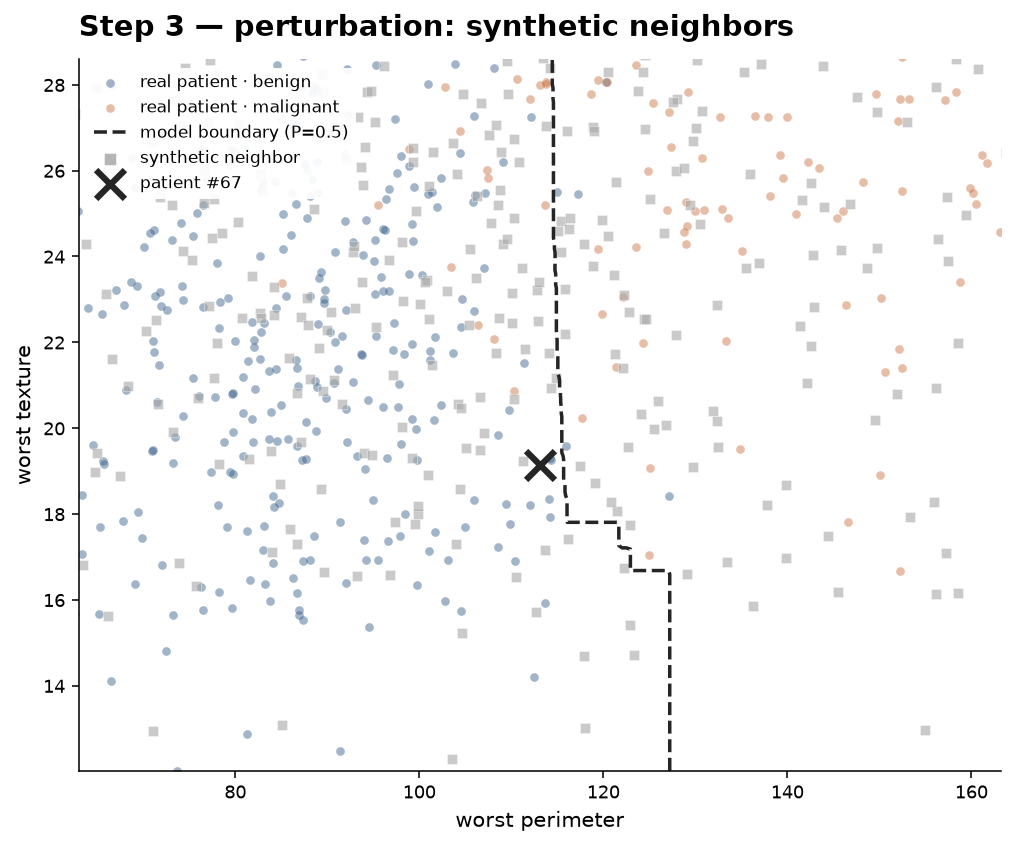

In [8]:
fig, ax = new_figure("Step 3 — perturbation: synthetic neighbors")
draw_base(ax)
draw_neighbors(ax, Z_vis, colors=GRAY, labels=[(GRAY, "synthetic neighbor")])
draw_patient(ax)
add_legend(ax)
save_figure(fig, "lime_step_3")
plt.show()

## Step 4 — what the model says about each neighbor

The only moment the real model is queried: `predict_proba` on every
synthetic neighbor.

**What to look for — and it is not what you might expect.** The squares
do *not* separate cleanly along the dashed boundary. They cannot: each
square has random values on the other 28 features, while the dashed
contour was computed holding those 28 fixed at *this patient's* values.
The cell prints how weak the agreement is. This is the picture of why a
2-D slice cannot determine a 30-D prediction — worth dwelling on before
anyone over-reads the geometry in the next steps.

in-frame neighbors whose prediction matches the side of the drawn contour: 68%
(majority-class baseline: 53% — so the contour explains little about them)


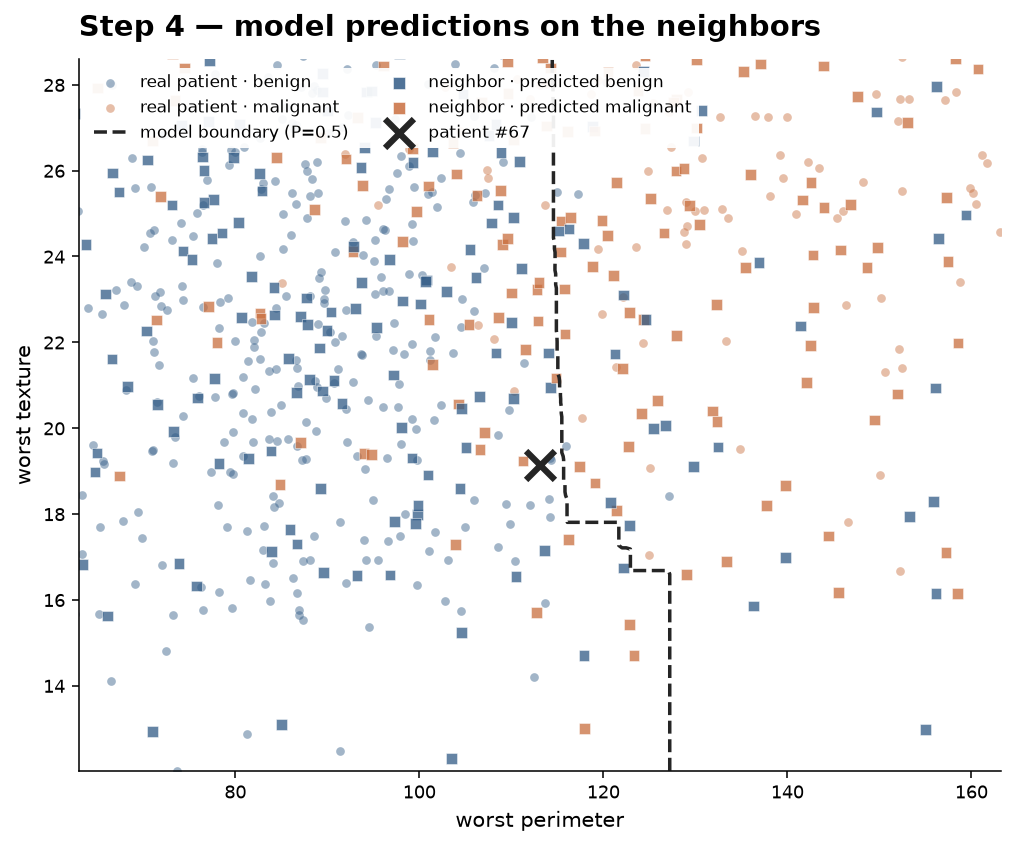

In [9]:
Z_vis_proba = model.predict_proba(Z_vis)[:, 1]
neighbor_colors = np.where(Z_vis_proba >= 0.5, BLUE, TERRACOTTA)

# do the neighbors agree with the side of the drawn contour they land on?
gi = np.clip(np.searchsorted(grid_x, Z_vis[in_window, ix]) - 1, 0, len(grid_x) - 2)
gj = np.clip(np.searchsorted(grid_y, Z_vis[in_window, iy]) - 1, 0, len(grid_y) - 2)
side_of_contour = PROB_SLICE[gj, gi] >= 0.5
agree = (side_of_contour == (Z_vis_proba[in_window] >= 0.5)).mean()
baseline = max((Z_vis_proba[in_window] >= 0.5).mean(), 1 - (Z_vis_proba[in_window] >= 0.5).mean())
print(f"in-frame neighbors whose prediction matches the side of the drawn contour: {agree:.0%}")
print(f"(majority-class baseline: {baseline:.0%} — so the contour explains little about them)")

fig, ax = new_figure("Step 4 — model predictions on the neighbors")
draw_base(ax)
draw_neighbors(ax, Z_vis, colors=neighbor_colors, sizes=30, alphas=0.75,
               labels=[(BLUE, "neighbor · predicted benign"),
                       (TERRACOTTA, "neighbor · predicted malignant")])
draw_patient(ax)
add_legend(ax, ncol=2)
save_figure(fig, "lime_step_4")
plt.show()

## Step 5 — proximity weighting

$$\pi_x(z) = \sqrt{\exp\!\left(-\dfrac{d(x,z)^2}{\nu^2}\right)}, \qquad \nu = 0.75\sqrt{30}$$

**What to look for:** square size and opacity now encode $\pi_x$ — the
first step where neighbors stop being equals. The distance is computed
over all **30 standardized** features, not the two on screen, so a square
that looks far from the ✕ can still be heavy if it resembles the patient
elsewhere. Sizes are faithful to the weights, not to on-screen distance.

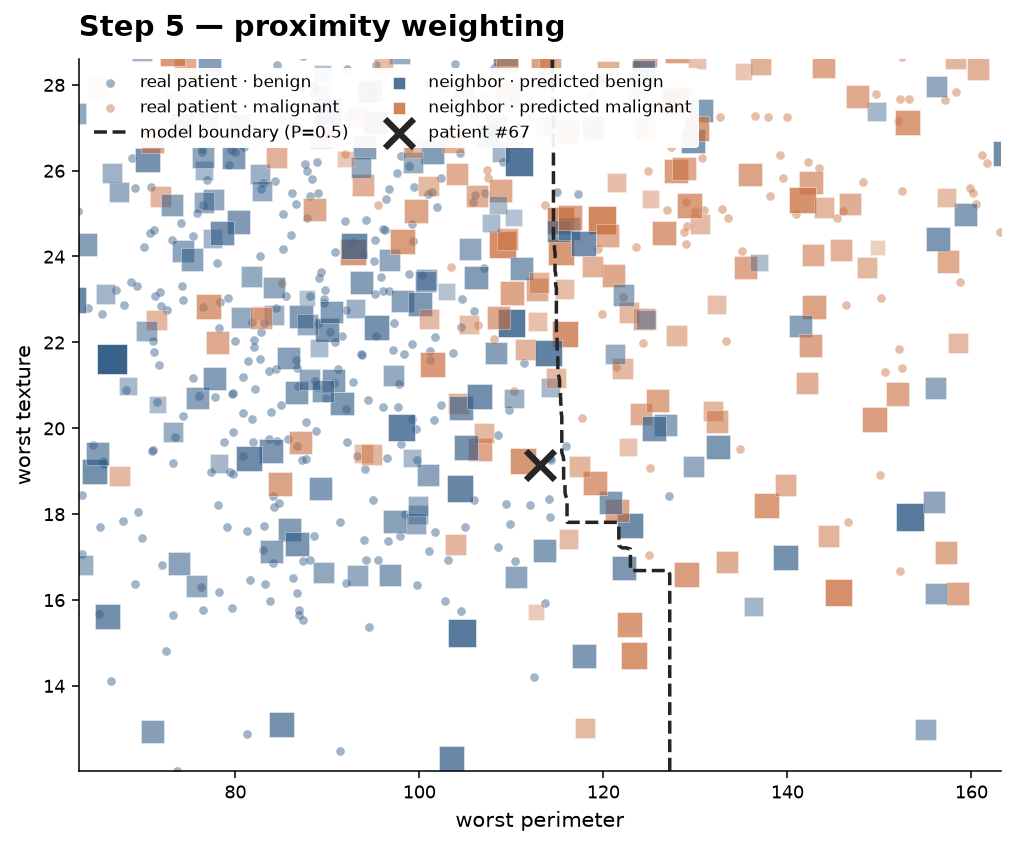

In [10]:
Z_vis_scaled = (Z_vis - train_mean) / train_std
dist_vis = np.linalg.norm(Z_vis_scaled - row_scaled, axis=1)
weight_vis = np.sqrt(np.exp(-(dist_vis ** 2) / (kernel_width ** 2)))
neighbor_sizes = 18 + 230 * (weight_vis / weight_vis.max())
neighbor_alphas = np.clip(0.18 + 0.78 * (weight_vis / weight_vis.max()), 0, 1)

fig, ax = new_figure("Step 5 — proximity weighting")
draw_base(ax)
draw_neighbors(ax, Z_vis, colors=neighbor_colors, sizes=neighbor_sizes, alphas=neighbor_alphas,
               labels=[(BLUE, "neighbor · predicted benign"),
                       (TERRACOTTA, "neighbor · predicted malignant")])
draw_patient(ax)
add_legend(ax, ncol=2)
save_figure(fig, "lime_step_5")
plt.show()

## Step 6 — the local fit

A Ridge regression ($\alpha=1$) on the 8 selected features, each neighbor
weighted by its $\pi_x$. What is drawn is the contour of that fit **through
the patient**.

That is a deliberate choice, and the reason is measured two cells below.
A linear fit gives you two things: a *direction* (the coefficient ratio)
and a *level* (the intercept). Here the direction is excellent and the
level is systematically wrong, so the figure shows the direction and
refuses to show the level. Drawing the fit's $P=0.5$ contour instead —
the conventional choice — would place this patient on the malignant side
of her own explanation.

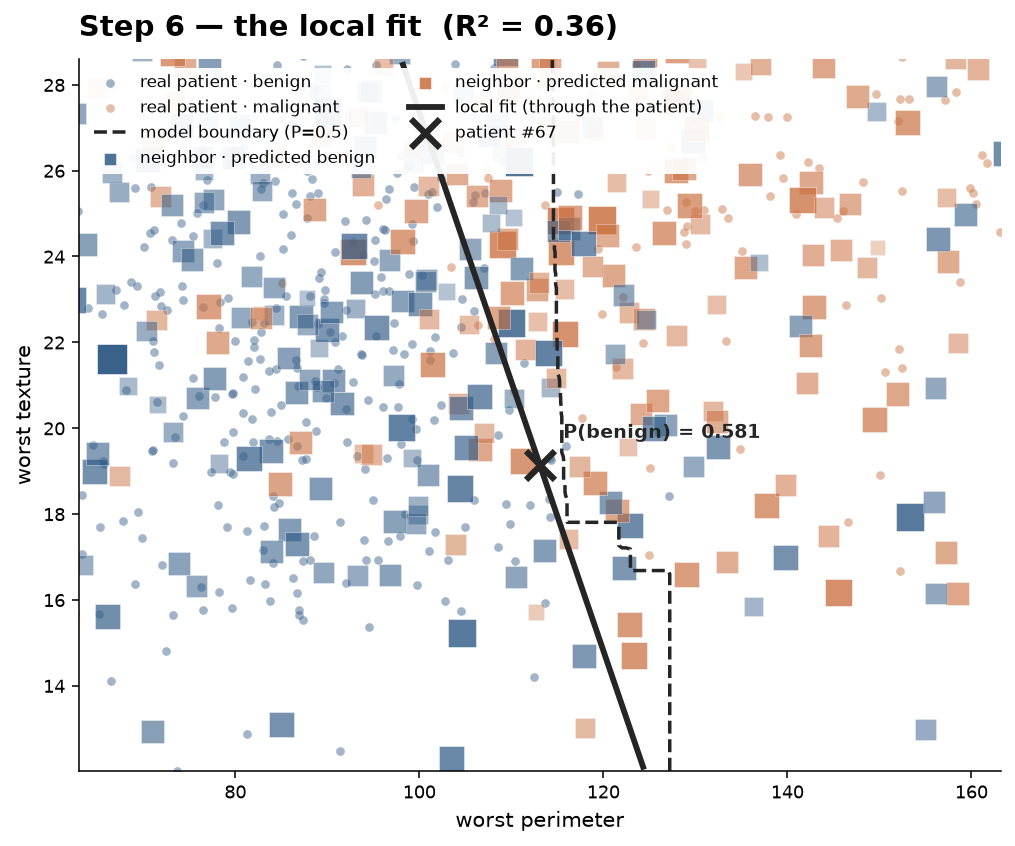

In [11]:
explainer = LimeTabularExplainer(
    X_train, feature_names=feature_names, class_names=class_names,
    discretize_continuous=False, random_state=RANDOM_STATE,
)
exp = explainer.explain_instance(
    row, model.predict_proba, num_features=8, num_samples=5000, labels=(1,)
)
r2 = exp.score
weights_map = {feature_names[f]: w for f, w in exp.local_exp[1]}
top_feat = max(weights_map, key=lambda f: abs(weights_map[f]))
i_top = feat_idx[top_feat]

fig, ax = new_figure(f"Step 6 — the local fit  (R² = {r2:.2f})")
draw_base(ax)
draw_neighbors(ax, Z_vis, colors=neighbor_colors, sizes=neighbor_sizes, alphas=neighbor_alphas,
               labels=[(BLUE, "neighbor · predicted benign"),
                       (TERRACOTTA, "neighbor · predicted malignant")])
fit_drawn = draw_local_fit(ax, exp)
draw_patient(ax, annotate=True)
add_legend(ax, ncol=2)
save_figure(fig, "lime_step_6")
plt.show()

### Is the direction right? Measure it.

The claim "the straight line approximates the boundary locally" is
testable: compare the direction of the fit's gradient to the direction in
which the real model's probability actually changes around the patient
(finite differences, ±0.3σ).

In [12]:
def numeric_gradient(h=0.3):
    g = np.zeros(len(feature_names))
    for j in range(len(feature_names)):
        a, b = row.copy(), row.copy()
        a[j] += h * train_std[j]
        b[j] -= h * train_std[j]
        g[j] = (model.predict_proba(a.reshape(1, -1))[0, 1]
                - model.predict_proba(b.reshape(1, -1))[0, 1]) / (2 * h)
    return g


grad_f = numeric_gradient()
cm = dict(exp.local_exp[1])
grad_g = np.zeros(len(feature_names))
for j, w in cm.items():
    grad_g[j] = w


def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))


ang_g = np.degrees(np.arctan2(grad_g[iy], grad_g[ix]))
ang_f = np.degrees(np.arctan2(grad_f[iy], grad_f[ix]))
print(f"direction of the fit, in the plotted plane:      {ang_g:+.1f}°")
print(f"direction the model actually changes (measured): {ang_f:+.1f}°")
print(f"disagreement: {abs(ang_g - ang_f):.1f}°   —   cosine similarity {cosine(grad_g[[ix, iy]], grad_f[[ix, iy]]):+.3f}")
print(f"\nbut across all 30 features, cosine(grad g, grad f) = {cosine(grad_g, grad_f):+.3f}")
print("→ in the plane we plot, the fit points almost exactly where the model does.")
print("  Across all 30 features it is only moderately aligned — so the ranking of")
print("  the smaller coefficients deserves far less confidence than the leading one.")

direction of the fit, in the plotted plane:      -163.3°
direction the model actually changes (measured): -167.4°
disagreement: 4.1°   —   cosine similarity +0.997

but across all 30 features, cosine(grad g, grad f) = +0.565
→ in the plane we plot, the fit points almost exactly where the model does.
  Across all 30 features it is only moderately aligned — so the ranking of
  the smaller coefficients deserves far less confidence than the leading one.


### Is the level right? Measure that too.

Same fit, different question: does $g$ reproduce the model's *value* at
the patient?

In [13]:
print(f"f(x), the real model:  {row_proba:.4f}   → {class_names[int(row_proba >= 0.5)]}")
print(f"g(x), the linear fit:  {exp.local_pred[0]:.4f}   → {class_names[int(exp.local_pred[0] >= 0.5)]}")
print(f"gap: {abs(row_proba - exp.local_pred[0]):.4f}")
print("\nacross 8 re-runs of LIME on this same patient:")
gxs = []
for s in range(8):
    e = LimeTabularExplainer(
        X_train, feature_names=feature_names, class_names=class_names,
        discretize_continuous=False, random_state=RANDOM_STATE + s,
    ).explain_instance(row, model.predict_proba, num_features=8, num_samples=5000, labels=(1,))
    gxs.append(e.local_pred[0])
gxs = np.array(gxs)
print(f"  g(x) = {gxs.mean():.4f} ± {gxs.std():.4f}   (f(x) = {row_proba:.4f})")
print(f"  lands on the correct side of 0.5 in {int((gxs >= 0.5).sum())}/8 runs")
print("\n→ the bias is stable, not noisy: g(x) reliably lands near 0.50 while the model")
print("  says 0.58. The intercept is pulled toward the mean of that huge off-manifold")
print("  cloud from step 3, whose average prediction is about 0.5. This is why the")
print("  figure above draws the fit through the patient rather than at P=0.5.")

f(x), the real model:  0.5812   → benign
g(x), the linear fit:  0.4968   → malignant
gap: 0.0843

across 8 re-runs of LIME on this same patient:


  g(x) = 0.4988 ± 0.0025   (f(x) = 0.5812)
  lands on the correct side of 0.5 in 3/8 runs

→ the bias is stable, not noisy: g(x) reliably lands near 0.50 while the model
  says 0.58. The intercept is pulled toward the mean of that huge off-manifold
  cloud from step 3, whose average prediction is about 0.5. This is why the
  figure above draws the fit through the patient rather than at P=0.5.


### What LIME actually hands you

The line is a teaching device. What the library returns, and what
practitioners read, is the coefficient list — the direction, decomposed
feature by feature.

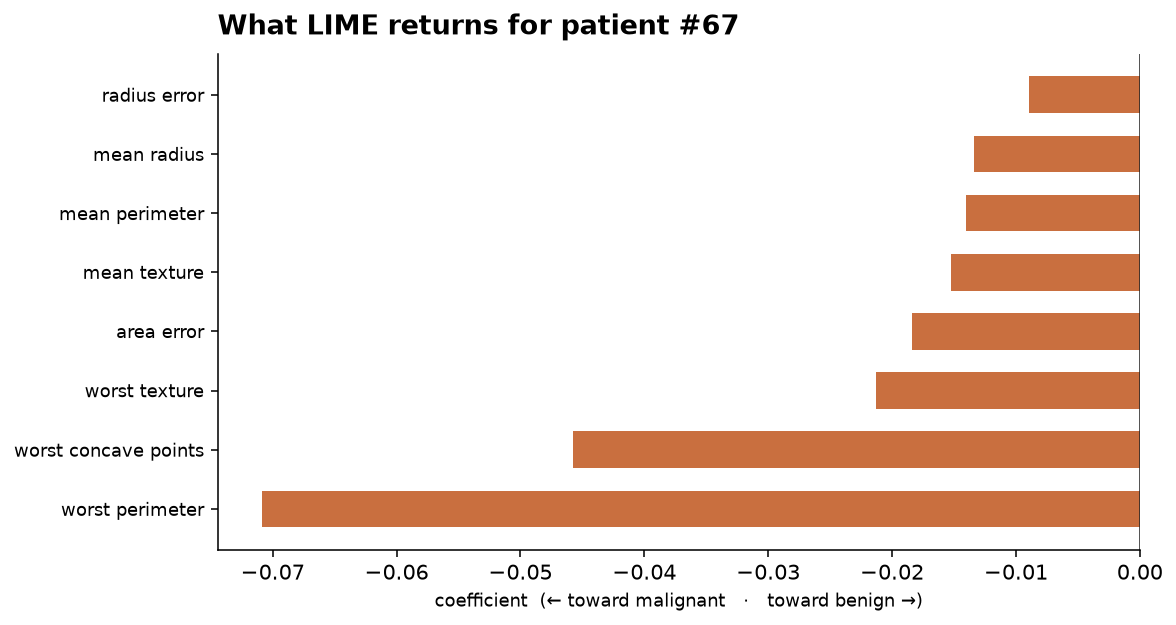

Every coefficient is negative: on this patient, all eight selected measurements
push toward malignant, and the model still returns benign — the remaining 22
features and the forest's nonlinearity carry the verdict. A local linear summary
cannot show you that; it is one of the things LIME structurally cannot say.


In [14]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
order = sorted(weights_map, key=lambda f: weights_map[f])
vals = [weights_map[f] for f in order]
ax.barh(order, vals, color=[BLUE if v > 0 else TERRACOTTA for v in vals], height=0.62)
ax.axvline(0, color=DARK, linewidth=0.8)
ax.set_title(f"What LIME returns for patient #{instance_idx}", loc="left",
             fontsize=14, fontweight="bold", pad=10)
ax.set_xlabel("coefficient  (← toward malignant   ·   toward benign →)", fontsize=9.5)
ax.tick_params(axis="y", labelsize=9)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
save_figure(fig, "lime_step_6b_coefficients")
plt.show()

print("Every coefficient is negative: on this patient, all eight selected measurements")
print("push toward malignant, and the model still returns benign — the remaining 22")
print("features and the forest's nonlinearity carry the verdict. A local linear summary")
print("cannot show you that; it is one of the things LIME structurally cannot say.")

## Fidelity: what R² does and does not mean

$R^2$ measures how well $g$ tracks $f$ across the weighted neighborhood.
It is tempting to read it as an explanation-quality score, prefer high
values, and distrust low ones. That reading does not survive measurement.

Across all 143 test patients, $R^2$ correlates with how *confident* the
prediction was — Spearman $\rho \approx +0.57$, $p \approx 8\times10^{-14}$
(computed in `lime_internals.ipynb`): mean $R^2$ of 0.45 for borderline
patients versus 0.60 for confident ones.

**The obvious explanation for this is wrong, and it is worth seeing why.**
One would guess: far from the boundary the model is saturated, its output
barely moves, and a straight line reproduces "almost constant" easily. Two
measurements kill that story:

In [15]:
Z_probe = Z_big
f_probe = model.predict_proba(Z_probe)[:, 1]
f_real = model.predict_proba(X_all)[:, 1]
print(f"f on LIME's synthetic cloud: range [{f_probe.min():.2f}, {f_probe.max():.2f}], "
      f"fraction saturated (<0.05 or >0.95): {((f_probe < .05) | (f_probe > .95)).mean():.3f}")
print(f"f on the REAL patients:      fraction saturated: "
      f"{((f_real < .05) | (f_real > .95)).mean():.1%}")

conf_all, wvar_all = [], []
for i in range(len(X_test)):
    dd = np.linalg.norm((Z_probe - train_mean) / train_std - (X_test[i] - train_mean) / train_std, axis=1)
    ww = np.sqrt(np.exp(-(dd ** 2) / kernel_width ** 2))
    mbar = np.average(f_probe, weights=ww)
    wvar_all.append(np.average((f_probe - mbar) ** 2, weights=ww))
    conf_all.append(abs(proba_test[i] - 0.5))
conf_all, wvar_all = np.array(conf_all), np.array(wvar_all)
b, c = conf_all < 0.15, conf_all > 0.30
print(f"\nweighted variance of f over the neighborhood:")
print(f"  borderline patients: {wvar_all[b].mean():.4f}")
print(f"  confident patients:  {wvar_all[c].mean():.4f}")

f on LIME's synthetic cloud: range [0.07, 0.97], fraction saturated (<0.05 or >0.95): 0.000
f on the REAL patients:      fraction saturated: 73.8%

weighted variance of f over the neighborhood:
  borderline patients: 0.0228
  confident patients:  0.0227


The model **never saturates anywhere LIME looks**: on the synthetic cloud
its output stays in a middling band, while on real patients three quarters
of predictions are saturated. LIME never visits that region — because,
as step 3 measured, the cloud is not made of possible patients. And the
weighted variance of $f$ is the same for borderline and confident
patients, because they share the same cloud.

There is also an algebraic problem with the saturation story: since
$R^2 = 1 - \mathrm{SSE}/\mathrm{SST}$, a near-constant target *shrinks*
SST and makes a high $R^2$ harder to reach, not easier. The story predicts
the opposite of the observed correlation.

**So what does explain it?** Confident patients do sit further from the
training centroid (about 4.8σ versus 2.7σ). The natural next step — that
this makes the kernel concentrate weight on fewer points, so the fit has
less to reconcile — is also not supported: the weight skew barely differs
between the groups, and the effective sample size stays at roughly 93% of
the nominal one, so the weights are close to uniform for everybody
(`lime_internals.ipynb` §7, §9).

The honest summary — and the one to carry out of this lecture — is that a
robust, replicated regularity exists, that both mechanisms one would
naturally reach for are falsified by measurement, and that we cannot say
why it happens. Saying so is better practice than a tidy story that does
not survive its own test. What follows for use is unchanged and concrete:
**do not read $R^2$ alone as evidence that an explanation is good.**

### One more thing the fit cannot do: stop

$g$ is linear and extrapolates forever; $f$ saturates. Push far enough
along the strongest feature and the "probability" leaves $[0,1]$.

In [16]:
print(f"moving only '{top_feat}', holding the other 29 fixed:")
for delta in [0, 1, 2, 4, 8]:
    probe = row.copy()
    probe[i_top] = row[i_top] + delta * train_std[i_top]
    real = model.predict_proba(probe.reshape(1, -1))[0, 1]
    zs = (probe - train_mean) / train_std
    lin = exp.intercept[1] + sum(w * zs[j] for j, w in cm.items())
    flag = "  ← outside [0,1]" if not (0 <= lin <= 1) else ""
    print(f"  +{delta}σ: model={real:.3f}   linear fit={lin:.3f}{flag}")

moving only 'worst perimeter', holding the other 29 fixed:
  +0σ: model=0.581   linear fit=0.497
  +1σ: model=0.478   linear fit=0.426
  +2σ: model=0.478   linear fit=0.355
  +4σ: model=0.478   linear fit=0.213
  +8σ: model=0.478   linear fit=-0.070  ← outside [0,1]


### What the book says

From Molnar,
[*Interpretable Machine Learning*, LIME chapter](https://christophm.github.io/interpretable-ml-book/lime.html):

> "The learned model should be a good approximation of the machine
> learning model predictions locally, but it does not have to be a good
> global approximation. This kind of accuracy is also called **local
> fidelity**."

> "The fidelity measure (...) gives us a good idea of how reliable the
> interpretable model is in explaining the black box predictions in the
> neighborhood of the data instance of interest."

Molnar lists several limitations of LIME; three of them appear
quantitatively in this notebook — the arbitrary **neighborhood
definition** (step 2), the **instability** of explanations across runs
(the g(x) spread above, and `lime_internals.ipynb` §9), and the sampling
of **unrealistic data points** that ignore feature correlation (step 3).

## The six steps, side by side

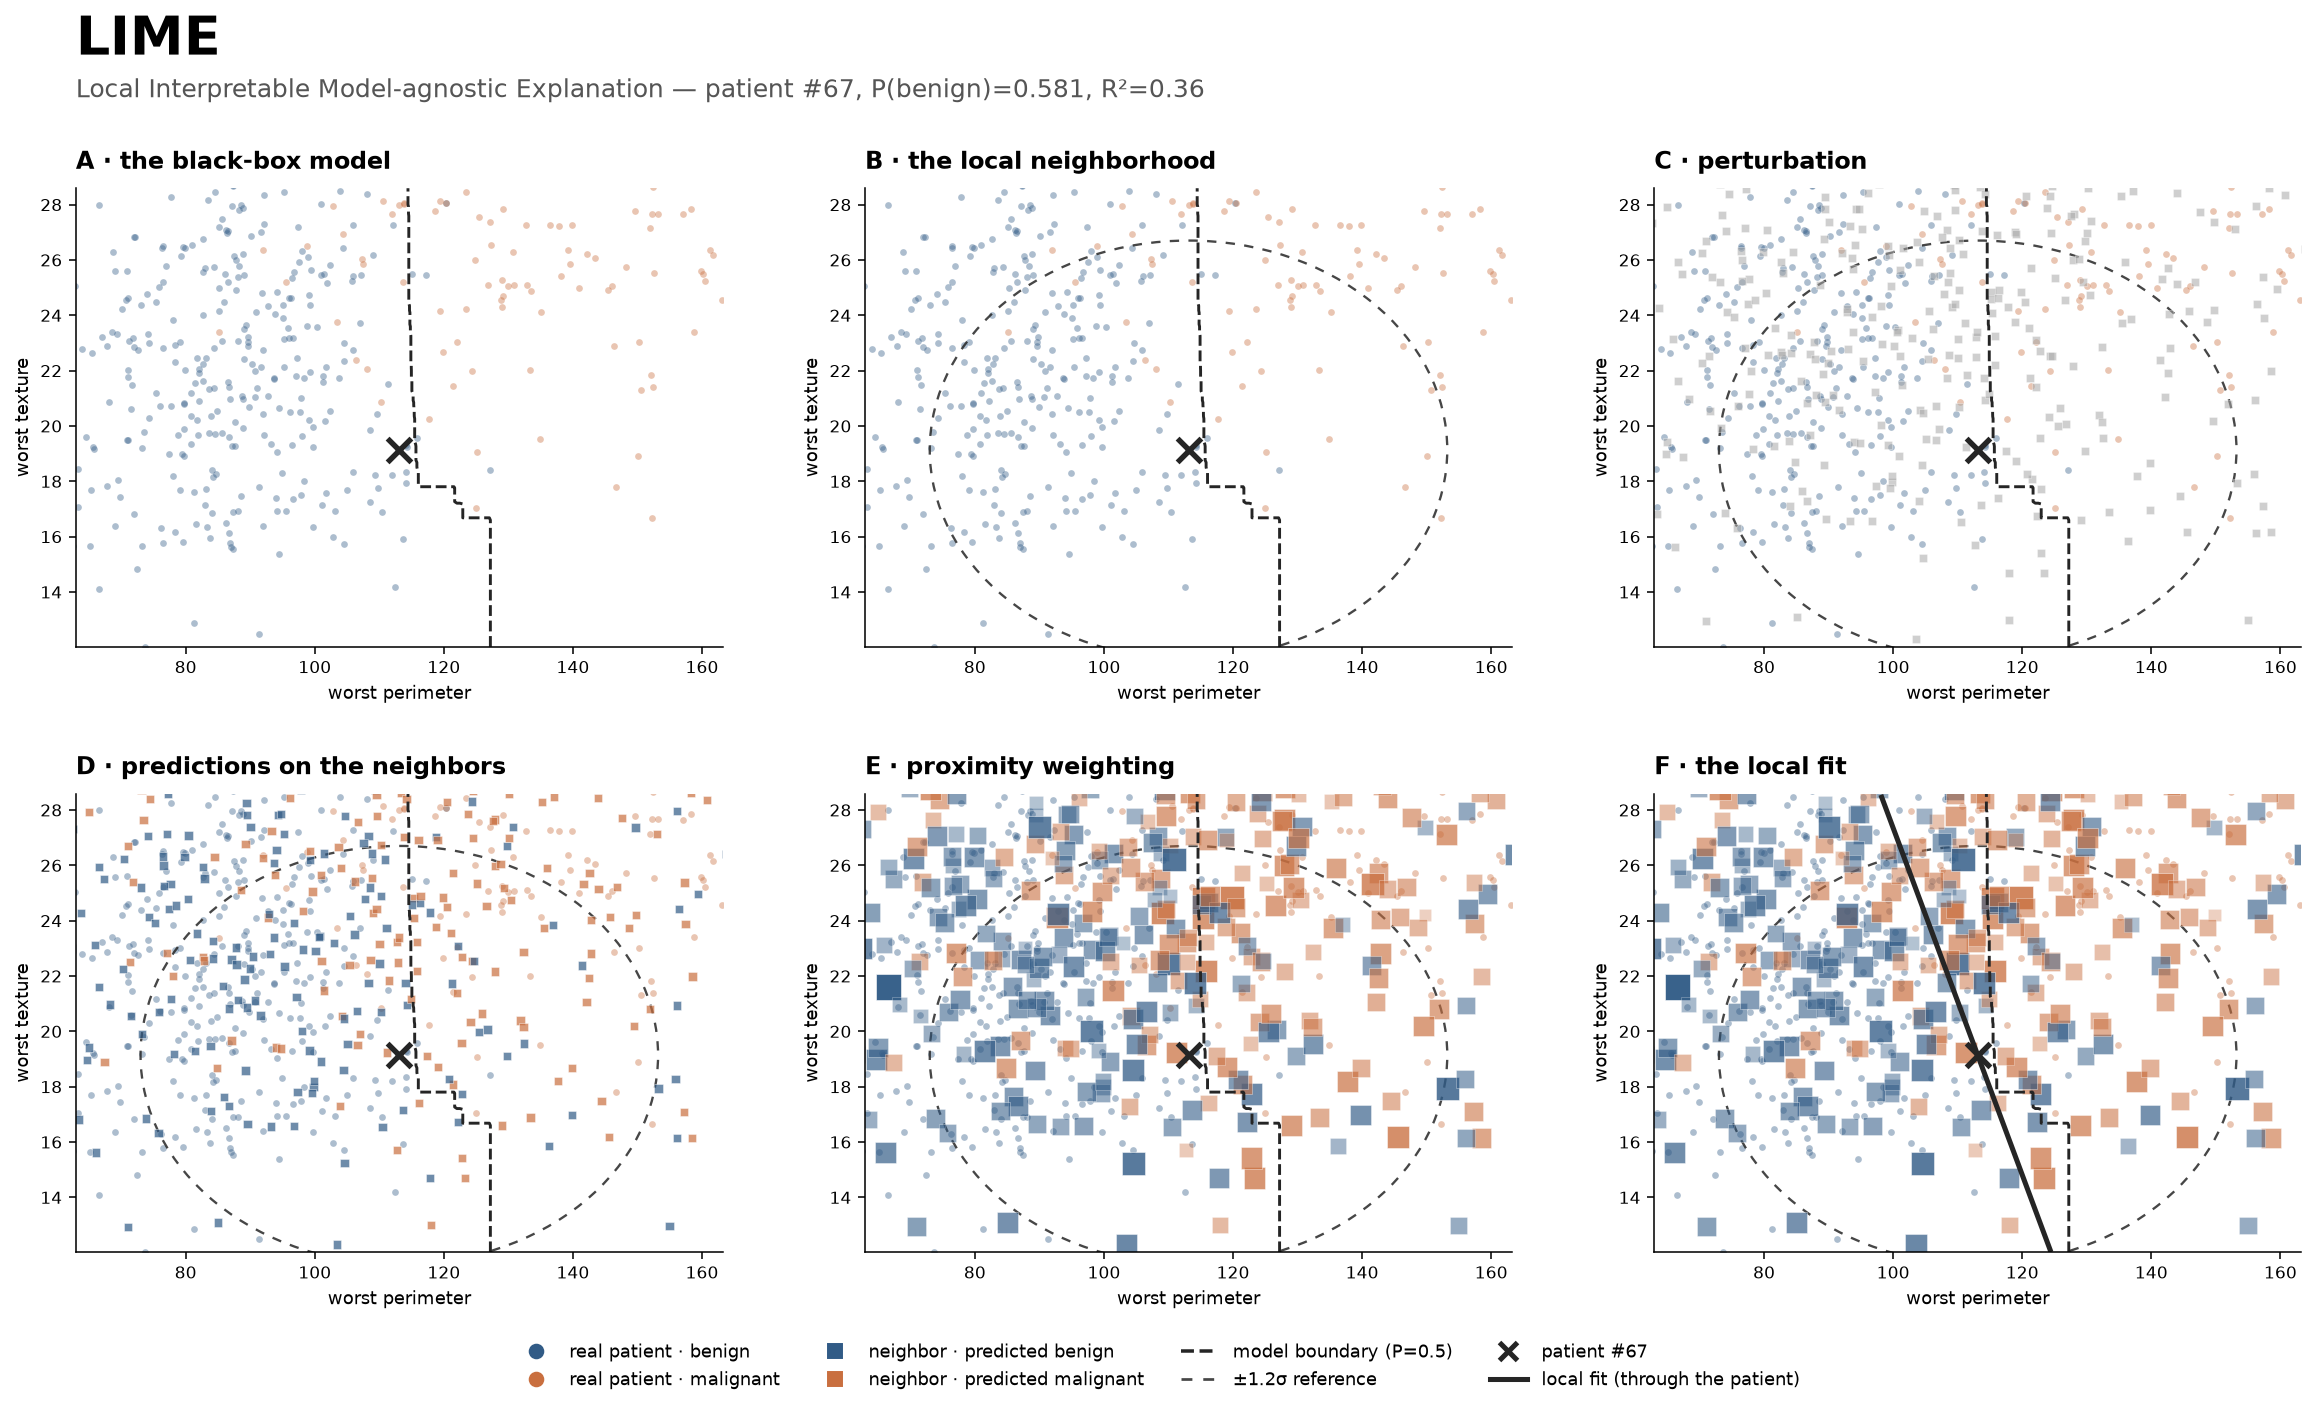

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.subplots_adjust(left=0.045, right=0.98, top=0.86, bottom=0.10, wspace=0.22, hspace=0.32)

panel_titles = [
    "A · the black-box model", "B · the local neighborhood", "C · perturbation",
    "D · predictions on the neighbors", "E · proximity weighting", "F · the local fit",
]
axA, axB, axC, axD, axE, axF = axes.ravel()

for ax, title in zip(axes.ravel(), panel_titles):
    ax.set_title(title, loc="left", fontsize=12.5, fontweight="bold", pad=10)
    ax.set_xlim(grid_x.min(), grid_x.max())
    ax.set_ylim(grid_y.min(), grid_y.max())
    ax.set_xlabel(axis_x_name, fontsize=9.5)
    ax.set_ylabel(axis_y_name, fontsize=9.5)
    ax.tick_params(labelsize=8.5)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    ax.scatter(X_all[y_all == 1, ix], X_all[y_all == 1, iy], s=12, color=BLUE, alpha=0.4, linewidth=0)
    ax.scatter(X_all[y_all == 0, ix], X_all[y_all == 0, iy], s=12, color=TERRACOTTA, alpha=0.4, linewidth=0)
    ax.contour(GX, GY, PROB_SLICE, levels=[0.5], colors=[DARK], linewidths=1.5, linestyles="--")

for ax in (axB, axC, axD, axE, axF):
    ax.add_patch(Ellipse((row[ix], row[iy]),
                         width=2.4 * train_std[ix], height=2.4 * train_std[iy],
                         fill=False, color=DARK, linewidth=1.2, linestyle=(0, (4, 4)), alpha=0.85))

axC.scatter(Z_vis[:, ix], Z_vis[:, iy], s=16, marker="s", color=GRAY, alpha=0.55,
            linewidth=0.3, edgecolors="white")
axD.scatter(Z_vis[:, ix], Z_vis[:, iy], s=18, marker="s", color=neighbor_colors, alpha=0.7,
            linewidth=0.3, edgecolors="white")
for ax in (axE, axF):
    ax.scatter(Z_vis[:, ix], Z_vis[:, iy], s=neighbor_sizes * 0.7, marker="s",
               color=neighbor_colors, alpha=neighbor_alphas, linewidth=0.3, edgecolors="white")

if fit_drawn:
    y_line, inside = local_isoline(exp, row, grid_x, grid_y)
    axF.plot(grid_x[inside], y_line[inside], color=DARK, linewidth=2.6)

for ax in (axA, axB, axC, axD, axE, axF):
    ax.scatter(row[ix], row[iy], s=150, marker="x", color=DARK, linewidths=2.8, zorder=20)

handles = [
    plt.Line2D([], [], marker="o", linestyle="", color=BLUE, markersize=7, label="real patient · benign"),
    plt.Line2D([], [], marker="o", linestyle="", color=TERRACOTTA, markersize=7, label="real patient · malignant"),
    plt.Line2D([], [], marker="s", linestyle="", color=BLUE, markersize=7, label="neighbor · predicted benign"),
    plt.Line2D([], [], marker="s", linestyle="", color=TERRACOTTA, markersize=7, label="neighbor · predicted malignant"),
    plt.Line2D([], [], color=DARK, linewidth=1.8, linestyle="--", label="model boundary (P=0.5)"),
    plt.Line2D([], [], color=DARK, linewidth=1.4, linestyle=(0, (4, 4)), alpha=0.85, label="±1.2σ reference"),
    plt.Line2D([], [], marker="x", linestyle="", color=DARK, markersize=9, markeredgewidth=2.6,
               label=f"patient #{instance_idx}"),
    plt.Line2D([], [], color=DARK, linewidth=2.6, label="local fit (through the patient)"),
]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=9.5, frameon=False,
           bbox_to_anchor=(0.5, -0.01))

fig.suptitle("LIME", fontsize=28, fontweight="bold", x=0.045, ha="left", y=0.985)
fig.text(0.045, 0.925,
         f"Local Interpretable Model-agnostic Explanation — patient #{instance_idx}, "
         f"P(benign)={row_proba:.3f}, R²={r2:.2f}",
         fontsize=13, color="#555555", ha="left")

save_figure(fig, "lime_walkthrough_combined")
fig.savefig(os.path.join(FIG_DIR, "lime_walkthrough_combined.pdf"), bbox_inches="tight")
plt.show()

## Closing — where explanations are needed most

The single test split used above is too small to characterise the model's
weak spot: only six of its 143 patients are borderline. Ten-fold
cross-validation over all 569 patients gives a usable sample.

In [18]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
p_cv = cross_val_predict(
    RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE),
    X_all, y_all, cv=cv, method="predict_proba")[:, 1]
pred_cv = (p_cv >= 0.5).astype(int)
conf_cv = np.abs(p_cv - 0.5)
print(f"10-fold CV over all {len(y_all)} patients: accuracy {accuracy_score(y_all, pred_cv):.1%}, "
      f"ROC-AUC {roc_auc_score(y_all, p_cv):.3f}")
for lo, hi, lab in [(0.30, 0.51, "confident  (|P-0.5| > 0.30)"),
                    (0.00, 0.15, "borderline (|P-0.5| < 0.15)")]:
    s = (conf_cv >= lo) & (conf_cv < hi)
    print(f"  {lab:30s} n={s.sum():3d} ({s.mean():.0%})   accuracy {accuracy_score(y_all[s], pred_cv[s]):.1%}")

10-fold CV over all 569 patients: accuracy 95.3%, ROC-AUC 0.989
  confident  (|P-0.5| > 0.30)    n=492 (86%)   accuracy 99.4%
  borderline (|P-0.5| < 0.15)    n= 34 (6%)   accuracy 52.9%


Where the model is confident it is essentially never wrong. Where it
hesitates — one patient in sixteen — it is barely better than a coin
flip. Those are the cases a clinician would actually bring to a second
opinion, and they are exactly the cases this lecture has been about.

What LIME gave us for one of them: a direction that matches the model's
real local behavior to within a few degrees in the plane we could draw, a
ranked list of which measurements pushed the verdict, and — once we
measured rather than assumed — a clear account of which parts of that
picture to trust. The level was biased, the 30-D coefficient ranking only
moderately reliable, and the neighborhood it reasoned over was made of
patients who could not exist.

LIME's value is not that it is never wrong. It is that, once you measure
it, you can say precisely how it is wrong — and that is the difference
between an explanation and a reassurance.